In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [5]:
df = pd.read_csv("../data/diabetes.csv")

In [6]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [7]:
df.shape

(768, 9)

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [9]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [10]:
(df == 0).sum()

Pregnancies                 111
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                     500
dtype: int64

### Data Quality Observation

Although no null values are present, several medical variables contain impossible zero values.

These zeros likely represent missing or unrecorded measurements.

The Insulin column contains 374 zero values, suggesting substantial missing data.

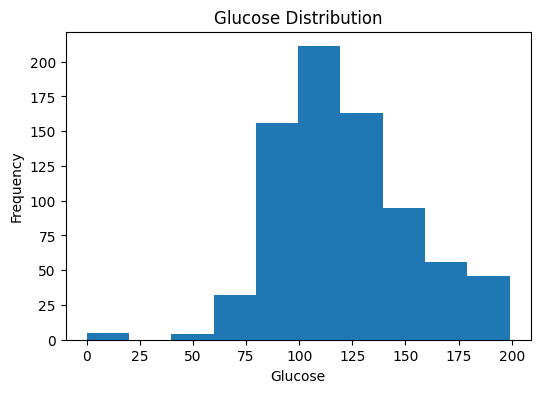

In [11]:
plt.figure(figsize=(6,4))

plt.hist(df["Glucose"])

plt.title("Glucose Distribution")
plt.xlabel("Glucose")
plt.ylabel("Frequency")

plt.savefig("../OUTPUTS/glucose_distribution.png")

plt.show()

### Glucose Distribution

Most patients have glucose levels between 80 and 140.

The distribution is approximately normal with a slight right skew.

A small number of zero values are present and may represent missing measurements.

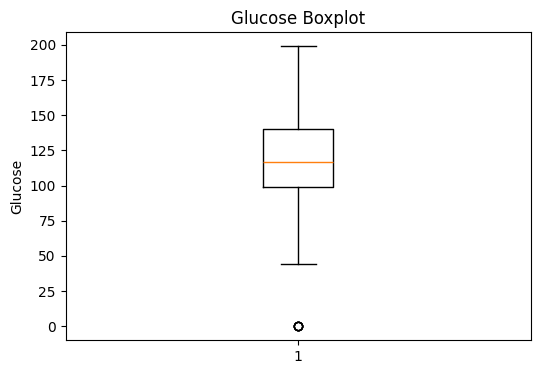

In [12]:
plt.figure(figsize=(6,4))

plt.boxplot(df["Glucose"])

plt.title("Glucose Boxplot")
plt.ylabel("Glucose")

plt.savefig("../OUTPUTS/glucose_boxplot.png")

plt.show()

### Glucose Outliers

A few extremely low glucose values are present.

These likely represent missing or incorrectly recorded data rather than true measurements.

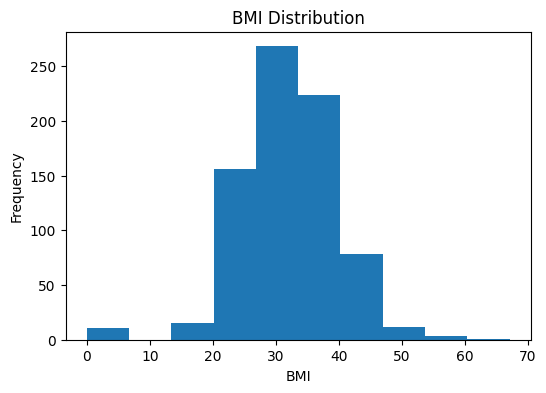

In [13]:
plt.figure(figsize=(6,4))

plt.hist(df["BMI"])

plt.title("BMI Distribution")
plt.xlabel("BMI")
plt.ylabel("Frequency")

plt.savefig("../OUTPUTS/bmi_distribution.png")

plt.show()

### BMI Distribution

Most patients have BMI values between 25 and 40.

The distribution shows a slight right skew.

Several patients exhibit very high BMI values, while a few zero values likely indicate missing data.

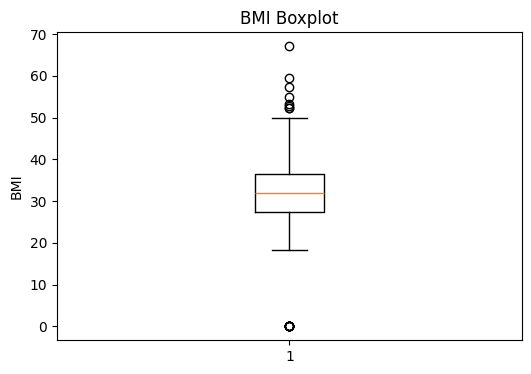

In [14]:
plt.figure(figsize=(6,4))

plt.boxplot(df["BMI"])

plt.title("BMI Boxplot")
plt.ylabel("BMI")

plt.savefig("../OUTPUTS/bmi_boxplot.png")

plt.show()

### BMI Outliers

One BMI value near zero appears invalid.

Several high BMI observations (>50) are present and likely represent genuine extreme cases rather than errors.

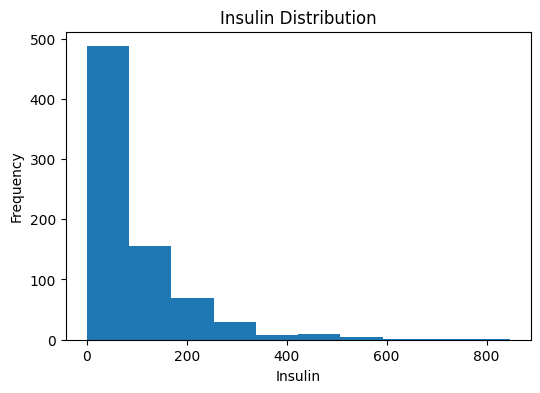

In [15]:
plt.figure(figsize=(6,4))

plt.hist(df["Insulin"])

plt.title("Insulin Distribution")
plt.xlabel("Insulin")
plt.ylabel("Frequency")

plt.savefig("../OUTPUTS/insulin_distribution.png")

plt.show()

### Insulin Distribution Analysis

The insulin distribution is highly right-skewed.

Most patients have relatively low insulin values, while a small number of observations exhibit extremely high insulin levels.

A large concentration of values near zero is also present, suggesting possible missing or unrecorded measurements.

The distribution is not symmetric and contains substantial variability.

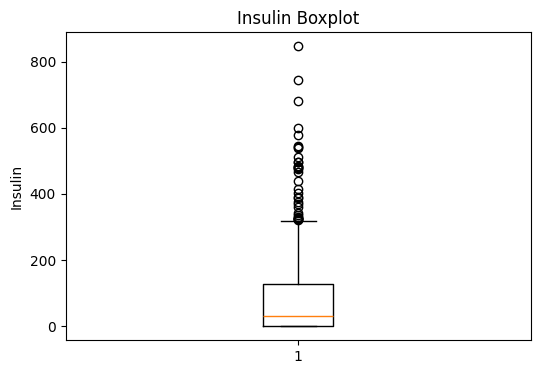

In [16]:
plt.figure(figsize=(6,4))

plt.boxplot(df["Insulin"])

plt.title("Insulin Boxplot")
plt.ylabel("Insulin")

plt.savefig("../OUTPUTS/insulin_boxplot.png")

plt.show()

### Insulin Outlier Analysis

The insulin variable contains a large number of extreme outliers.

Most observations are concentrated below 150, while several values extend beyond 800.

Additionally, a significant number of observations contain an insulin value of zero, which is likely indicative of missing or unrecorded measurements.

The presence of numerous outliers and zero values suggests that this variable may require additional cleaning before further statistical analysis.

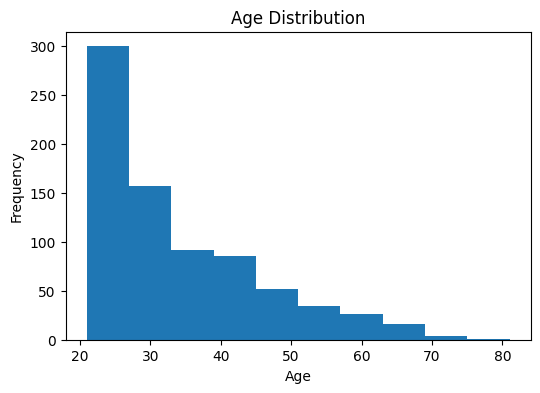

In [17]:
plt.figure(figsize=(6,4))

plt.hist(df["Age"])

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")

plt.savefig("../OUTPUTS/age_distribution.png")

plt.show()

### Age Distribution Analysis

The age distribution is strongly right-skewed.

Most patients in the dataset are between 20 and 35 years old, with the frequency of observations decreasing as age increases.

The dataset contains relatively few older individuals, indicating that younger patients make up the majority of the study population.

The distribution suggests that age is not evenly represented across all age groups.

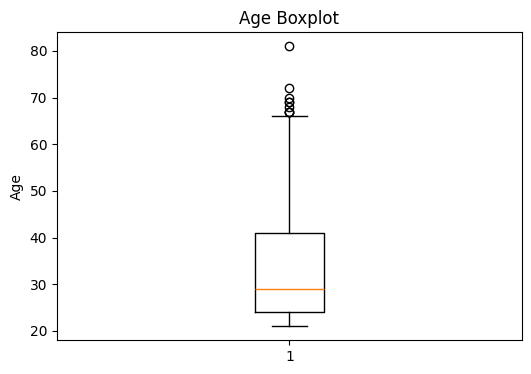

In [18]:
plt.figure(figsize=(6,4))

plt.boxplot(df["Age"])

plt.title("Age Boxplot")
plt.ylabel("Age")

plt.savefig("../OUTPUTS/age_boxplot.png")

plt.show()

### Age Outlier Analysis

The age variable contains a small number of high-value observations.

These observations correspond to older individuals and appear to be realistic rather than data-entry errors.

Unlike the BMI and Insulin variables, no suspicious zero values or extreme anomalies are observed.

The age data appears to be relatively clean and suitable for further analysis.

In [19]:
df["Outcome"].value_counts()

Outcome
0    500
1    268
Name: count, dtype: int64

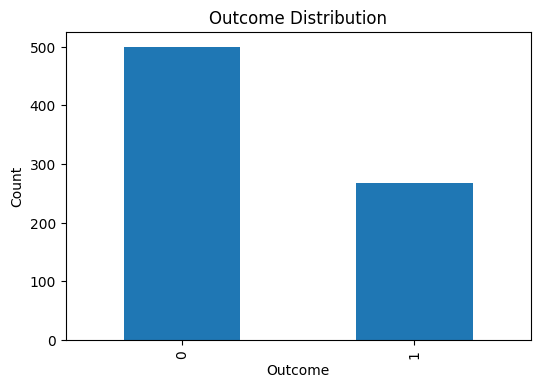

In [20]:

plt.figure(figsize=(6,4))

df["Outcome"].value_counts().plot(kind="bar")

plt.title("Outcome Distribution")
plt.xlabel("Outcome")
plt.ylabel("Count")

plt.savefig("../OUTPUTS/outcome_distribution.png")

plt.show()

### Outcome Distribution Analysis

The outcome variable represents whether a patient has diabetes (1) or does not have diabetes (0).

The dataset contains a larger number of non-diabetic patients compared to diabetic patients.

Although both classes are represented, the distribution is not perfectly balanced.

This imbalance should be considered when interpreting results and performing further analysis.

In [21]:
(df["Outcome"].value_counts(normalize=True) * 100).round(2)

Outcome
0    65.1
1    34.9
Name: proportion, dtype: float64

### Outcome Percentage Analysis

Approximately one-third of the patients in the dataset are diabetic, while the remaining patients are non-diabetic.

The prevalence of diabetes within this dataset is therefore substantial and provides sufficient observations for comparative analysis.

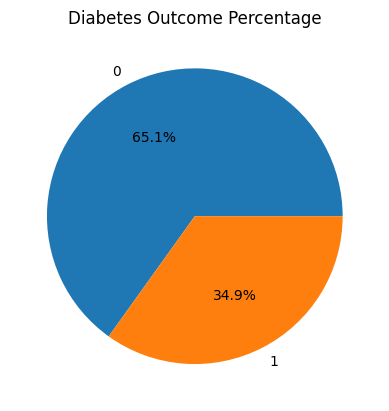

In [22]:
df["Outcome"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.title("Diabetes Outcome Percentage")

plt.ylabel("")

plt.show()



##  Comparative Analysis: Diabetic  VS  Non-Diabetic Patients

In [23]:
df.groupby("Outcome")["Glucose"].mean()

Outcome
0    109.980000
1    141.257463
Name: Glucose, dtype: float64

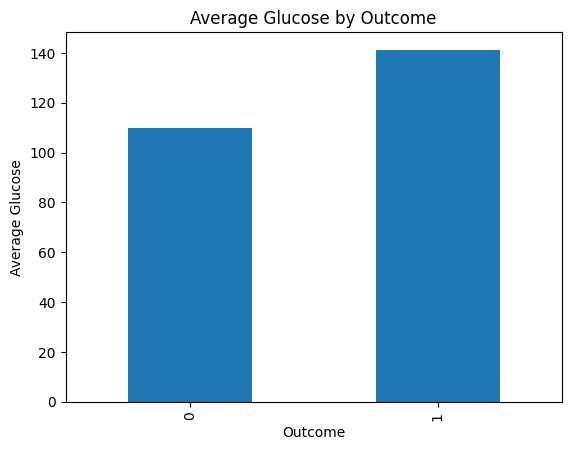

In [24]:
df.groupby("Outcome")["Glucose"].mean().plot(kind="bar")

plt.title("Average Glucose by Outcome")
plt.xlabel("Outcome")
plt.ylabel("Average Glucose")

plt.show()

#### Glucose Comparison

Diabetic patients have a significantly higher average glucose level (141.26) compared to non-diabetic patients (109.98).

This substantial difference suggests that elevated glucose levels are strongly associated with diabetes.

In [25]:
df.groupby("Outcome")["BMI"].mean()

Outcome
0    30.304200
1    35.142537
Name: BMI, dtype: float64

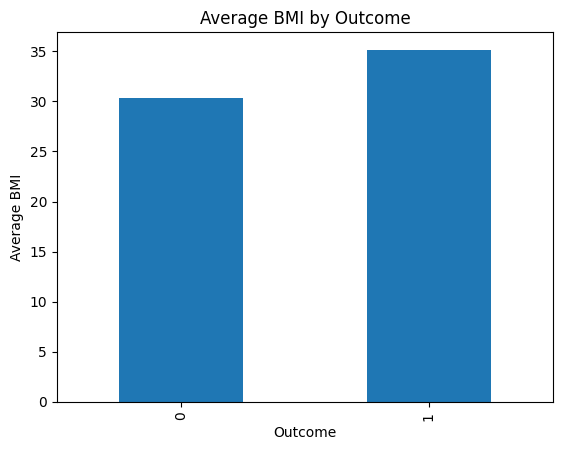

In [26]:
df.groupby("Outcome")["BMI"].mean().plot(kind="bar")

plt.title("Average BMI by Outcome")
plt.xlabel("Outcome")
plt.ylabel("Average BMI")

plt.show()

#### BMI Comparison

The average BMI of diabetic patients (35.14) is higher than that of non-diabetic patients (30.30).

This finding indicates that higher body mass index may be associated with an increased likelihood of diabetes.

In [27]:
df.groupby("Outcome")["Insulin"].mean()

Outcome
0     68.792000
1    100.335821
Name: Insulin, dtype: float64

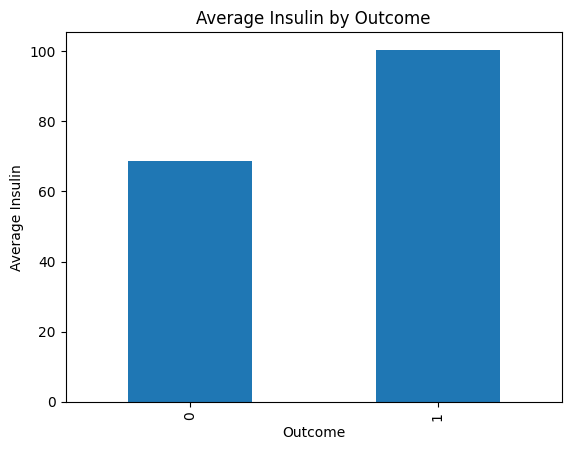

In [28]:
df.groupby("Outcome")["Insulin"].mean().plot(kind="bar")

plt.title("Average Insulin by Outcome")
plt.xlabel("Outcome")
plt.ylabel("Average Insulin")

plt.show()

#### Insulin Comparison

Diabetic patients exhibit higher average insulin levels (100.34) compared to non-diabetic patients (68.79).

However, the insulin variable contains many missing or zero values and several extreme outliers, which may influence the average.

In [29]:
df.groupby("Outcome")["Age"].mean()

Outcome
0    31.190000
1    37.067164
Name: Age, dtype: float64

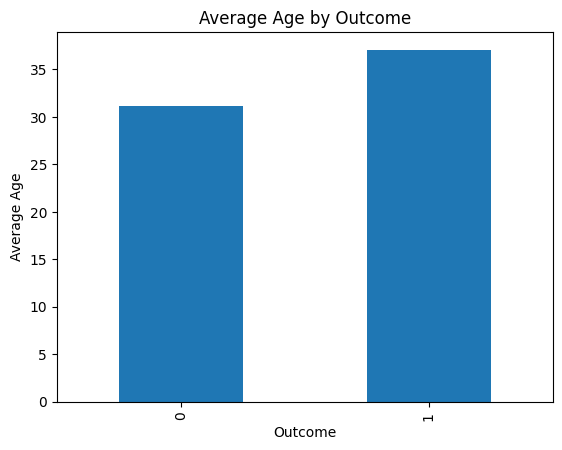

In [30]:
df.groupby("Outcome")["Age"].mean().plot(kind="bar")

plt.title("Average Age by Outcome")
plt.xlabel("Outcome")
plt.ylabel("Average Age")

plt.show()

#### Age Comparison

The average age of diabetic patients (37.07 years) is higher than that of non-diabetic patients (31.19 years).

This suggests that diabetes is more common among older individuals in this dataset.

## Comparative Analysis Conclusion

The comparative analysis reveals clear differences between diabetic and non-diabetic patients.

Diabetic patients tend to have:

- Higher glucose levels
- Higher BMI values
- Higher insulin levels
- Greater average age

Among all variables examined, glucose shows the largest difference between the two groups, indicating that it may be one of the strongest factors associated with diabetes.

These findings are consistent with established medical knowledge regarding diabetes risk factors and characteristics.

## Correlation Analysis

In [31]:
df.corr()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
Pregnancies,1.000000,0.129459,0.141282,-0.081672,-0.073535,0.017683,-0.033523,0.544341,0.221898
Glucose,0.129459,1.000000,0.152590,0.057328,0.331357,0.221071,0.137337,0.263514,0.466581
BloodPressure,0.141282,0.152590,1.000000,0.207371,0.088933,0.281805,0.041265,0.239528,0.065068
SkinThickness,-0.081672,0.057328,0.207371,1.000000,0.436783,0.392573,0.183928,-0.113970,0.074752
Insulin,-0.073535,0.331357,0.088933,0.436783,1.000000,0.197859,0.185071,-0.042163,0.130548
BMI,0.017683,0.221071,0.281805,0.392573,0.197859,1.000000,0.140647,0.036242,0.292695
DiabetesPedigreeFunction,-0.033523,0.137337,0.041265,0.183928,0.185071,0.140647,1.000000,0.033561,0.173844
Age,0.544341,0.263514,0.239528,-0.113970,-0.042163,0.036242,0.033561,1.000000,0.238356
Outcome,0.221898,0.466581,0.065068,0.074752,0.130548,0.292695,0.173844,0.238356,1.000000


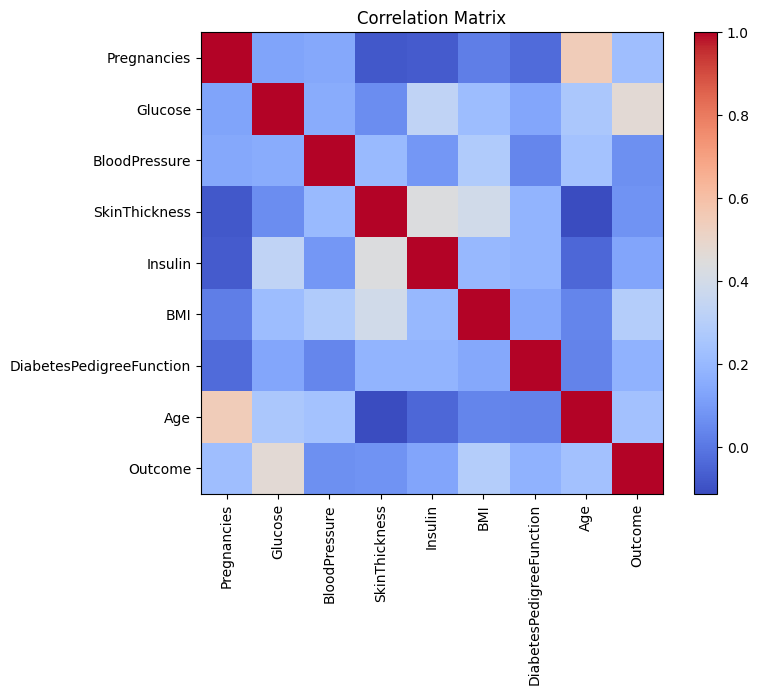

In [32]:
plt.figure(figsize=(8,6))

plt.imshow(df.corr(), cmap="coolwarm")

plt.colorbar()

plt.xticks(range(len(df.columns)), df.columns, rotation=90)
plt.yticks(range(len(df.columns)), df.columns)

plt.title("Correlation Matrix")

plt.savefig("../OUTPUTS/correlation_matrix.png")

plt.show()

## Correlation Analysis Conclusion

The correlation matrix reveals that glucose has the strongest relationship with diabetes outcome, followed by BMI, age, and number of pregnancies.

Key observations include:

- Glucose exhibits the strongest positive correlation with diabetes (0.467).
- BMI shows a moderate positive correlation with diabetes (0.293).
- Age and pregnancies also demonstrate positive relationships with diabetes occurrence.
- Blood pressure and skin thickness exhibit relatively weak correlations with diabetes.

These findings suggest that glucose level, BMI, and age are among the most important variables associated with diabetes in this dataset.

# Final Conclusion

This exploratory data analysis was conducted on the Pima Indians Diabetes Dataset to identify factors associated with diabetes.

Key findings include:

- The dataset contains 768 patient records and 9 variables.
- Several variables, particularly Glucose, BMI, and Insulin, contain zero values that likely represent missing measurements.
- Diabetic patients exhibit higher average glucose levels, BMI values, insulin levels, and age compared to non-diabetic patients.
- Glucose demonstrated the strongest correlation with diabetes outcome, making it the most influential variable in the dataset.
- BMI and age also showed meaningful associations with diabetes.

Overall, the analysis indicates that elevated glucose levels, higher BMI, and increasing age are important characteristics associated with diabetes within this dataset.